In [280]:
import os
import torch
import torch.nn as nn
import torchvision
from torchinfo import summary
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from itertools import combinations

In [281]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1, stride=1),    # (1, 28, 28) -> (32, 28, 28)
            nn.MaxPool2d(kernel_size=2, stride=2),    # (32, 28, 28) -> (32, 14, 14)
            nn.ReLU(),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=1),    # (32, 14, 14) -> (64, 14, 14)
            nn.MaxPool2d(kernel_size=2, stride=2),    # (64, 14, 14) -> (64, 7, 7)
            nn.ReLU(),
        )

        self.mu_layer = nn.Linear(64*7*7, latent_dim)    # (1, 64*7*7) -> (1, latent_dim)
        self.logvar_layer = nn.Linear(64*7*7, latent_dim)    # (1, 64*7*7) -> (1, latent_dim)
    
    def forward(self, img):
        x = self.conv_layers(img)
        x = x.view(x.size(0), -1)    # (64, 7, 7) -> (1, 64*7*7)

        mu = self.mu_layer(x)
        logvar = self.logvar_layer(x)

        return mu, logvar

In [282]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.fcnn_layer = nn.Linear(latent_dim, 64*7*7)    # (1, latent_dim) -> (1, 64*7*7)

        self.conv_layers = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, padding=1, stride=2),    # (64, 7, 7) -> (32, 14, 14)
            nn.ReLU(),

            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=4, padding=1, stride=2),    # (32, 14, 14) -> (3, 28, 28)
            nn.Sigmoid(),
        )
    
    def forward(self, latent):
        x = self.fcnn_layer(latent)
        x = x.view(x.size(0), 64, 7, 7)    # (1, 64*7*7) -> (64, 7, 7)

        img = self.conv_layers(x)
        return img

In [283]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    
    def forward(self, img):
        mu, logvar = self.encoder(img)

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        
        out = self.decoder(z)
        return out, mu, logvar

In [284]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

latent_dim = 4
vae = VAE(latent_dim)
vae = vae.to(device)
vae_model_path = "task1_results/best_model.pt"
vae.load_state_dict(torch.load(vae_model_path))

# Freezing the VAE parameters
for p in vae.parameters():
    p.requires_grad = False

Using device cuda


In [285]:
transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

print(f"Using device {device}")

train_data_raw = torchvision.datasets.MNIST(root="mnist", train=True, download=True, transform=transforms)
test_data_raw = torchvision.datasets.MNIST(root="mnist", train=False, download=True, transform=transforms)

indices = (train_data_raw.targets == 1) | (train_data_raw.targets == 2)
train_data_raw.data = train_data_raw.data[indices]
train_data_raw.targets = train_data_raw.targets[indices]

indices = (test_data_raw.targets == 1) | (test_data_raw.targets == 2)
test_data_raw.data = test_data_raw.data[indices]
test_data_raw.targets = test_data_raw.targets[indices]

# Since we deal only with 1 and 2, we can treat this as binary classification problem
train_data_raw.targets = (train_data_raw.targets == 2).long()
test_data_raw.targets  = (test_data_raw.targets == 2).long()

Using device cuda


In [286]:
batch_size = 64
train_dataloader = DataLoader(train_data_raw, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=4)
test_dataloader = DataLoader(test_data_raw, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4)

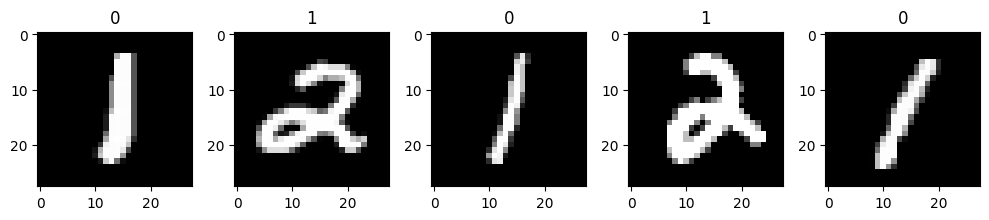

In [287]:
with torch.no_grad():
    for img, label in train_dataloader:
        fig, axes = plt.subplots(1, 5, figsize=(10, 12))
        for i in range(5):
            axes[i].imshow(img[i].squeeze(0), cmap="gray")
            axes[i].set_title(label[i].item())

        plt.tight_layout()
        plt.show()
        break

In [288]:
class Oracle(nn.Module):
    """ 
    This MLP is used as an oracle which takes in the latent embeddings and output the logits for each digits (only 1 here since we deal only with 1 and 2)
    """
    def __init__(self, latent_dim):
        super().__init__()

        self.mlp_layers = nn.Sequential(
            nn.Linear(latent_dim, 128),    # (1, latent_dim) -> (1, 128)
            nn.ReLU(),

            nn.Linear(128, 128),    # (1, 128) -> (1, 128)
            nn.ReLU(),
            
            nn.Linear(128, 1),    # (1, 128) -> (1, 1)
        )

        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        logits = self.mlp_layers(x)
        z = self.sigmoid(logits)
        
        return z, logits

In [289]:
def train_oracle_one_epoch(model, vae, train_dataloader, test_dataloader, loss_func, optimizer, device):
    train_loss = 0

    model.train()
    vae.eval()
    for img, label in train_dataloader:
        img = img.to(device)
        label = label.to(device)

        img_latent_mu, img_latent_logvar = vae.encoder(img)
        pred, logits = model(img_latent_mu)

        optimizer.zero_grad()
        loss = loss_func(pred, label.unsqueeze(1).float())
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    
    test_loss = 0

    model.eval()
    vae.eval()
    with torch.no_grad():
        for img, label in test_dataloader:
            img = img.to(device)
            label = label.to(device)

            img_latent_mu, img_latent_logvar = vae.encoder(img)
            pred, logits = model(img_latent_mu)

            loss = loss_func(pred, label.unsqueeze(1).float())
            test_loss += loss.item()
    
    train_loss /= len(train_dataloader)   
    test_loss /= len(test_dataloader)  

    return train_loss, test_loss

In [290]:
def visualize(model, vae, test_dataloader, epoch, device):
    sample_in = []
    sample_out = []
    sample_true = []

    all_mu = []
    all_label = []

    model.eval()
    vae.eval()
    with torch.no_grad():
        for img, label in test_dataloader:
            img = img.to(device)
            label = label.to(device)

            img_latent_mu, img_latent_logvar = vae.encoder(img)
            pred, logits = model(img_latent_mu)

            if (len(sample_in) == 0):
                sample_in.append(img)    
                sample_out.append(pred)
                sample_true.append(label)
            
            all_mu.append(img_latent_mu)
            all_label.append(label)
    
    sample_in = torch.cat(sample_in, dim=0)
    sample_out = torch.cat(sample_out, dim=0)
    sample_true = torch.cat(sample_true, dim=0)
    all_mu = torch.cat(all_mu, dim=0)
    all_label = torch.cat(all_label, dim=0)

    all_mu = all_mu.cpu()
    all_label = all_label.cpu()

    pca = PCA(n_components=2)
    all_mu_2d = pca.fit_transform(all_mu.numpy())

    x_coords, y_coords = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
    grid_points_2d = torch.tensor(np.stack([x_coords.flatten(), y_coords.flatten()], axis=1)).float().to(device)
    grid_points_latent = torch.tensor(pca.inverse_transform(grid_points_2d.cpu().numpy())).float().to(device)    # Mapping PCA dim to latent dim for model to make predicitons

    with torch.no_grad():
        preds, logits = model(grid_points_latent) 
        grid_preds = preds.cpu().numpy()

    plt.figure(figsize=(8,6))
    plt.contourf(x_coords, y_coords, grid_preds.reshape(100,100), levels=50, cmap="RdBu")
    plt.scatter(all_mu_2d[:,0], all_mu_2d[:,1], c=all_label.numpy(), cmap="RdBu", s=5)
    plt.colorbar()
    plt.savefig(f"task3_results/oracle/contours_epoch_{epoch}.png")
    plt.close()

    fig, axes = plt.subplots(5, 1, figsize=(6, 12))
    for i in range(5):
        axes[i].imshow(sample_in[i].squeeze(0).cpu(), cmap="gray")
        axes[i].set_title(f"Actual: {sample_true[i]} | Pred: {sample_out[i].item():.2f}")
    
    plt.tight_layout()
    plt.savefig(f"task3_results/oracle/output_epoch_{epoch}.png")
    plt.close()


In [291]:
def train_oracle(num_epochs, model, vae, train_dataloader, test_dataloader, loss_func, optimizer, device, patience):
    train_losses = []
    test_losses = []

    best_test_loss = float("inf")
    patience_count = 0
    for epoch in range(num_epochs):
        train_loss, test_loss = train_oracle_one_epoch(model, vae, train_dataloader, test_dataloader, loss_func, optimizer, device)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
        if (epoch % 10 == 0):
            visualize(model, vae, test_dataloader, epoch, device)
            print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | test_loss: {test_loss:.4f}")

        if (test_loss < best_test_loss):
            patience_count = 0
            best_test_loss = test_loss
            torch.save(model.state_dict(), "task3_results/oracle/best_model.pt")
        else:
            patience_count += 1
            if (patience_count >= patience):
                print("Early stopping")
                break

    return train_losses, test_losses

In [292]:
latent_dim = 4
oracle = Oracle(latent_dim)
oracle = oracle.to(device)

summary(oracle, (16, 1, 4))

Layer (type:depth-idx)                   Output Shape              Param #
Oracle                                   [16, 1, 1]                --
├─Sequential: 1-1                        [16, 1, 1]                --
│    └─Linear: 2-1                       [16, 1, 128]              640
│    └─ReLU: 2-2                         [16, 1, 128]              --
│    └─Linear: 2-3                       [16, 1, 128]              16,512
│    └─ReLU: 2-4                         [16, 1, 128]              --
│    └─Linear: 2-5                       [16, 1, 1]                129
├─Sigmoid: 1-2                           [16, 1, 1]                --
Total params: 17,281
Trainable params: 17,281
Non-trainable params: 0
Total mult-adds (M): 0.28
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.07
Estimated Total Size (MB): 0.10

In [293]:
if not (os.path.exists("task3_results/oracle/best_model.pt")):
    os.makedirs("task3_results", exist_ok=True)
    os.makedirs("task3_results/oracle", exist_ok=True)
    num_epochs = 75
    beta = 1
    lr = 1e-4
    patience = 5
    loss_func = nn.MSELoss(reduction="mean")
    optimizer = torch.optim.Adam(oracle.parameters(), lr=lr)

    train_losses, test_losses = train_oracle(num_epochs, oracle, vae, train_dataloader, test_dataloader, loss_func, optimizer, device, patience)

In [294]:
latent_dim = 4
oracle = Oracle(latent_dim)
oracle = oracle.to(device)
oracle_model_path = "task3_results/oracle/best_model.pt"
oracle.load_state_dict(torch.load(oracle_model_path))

<All keys matched successfully>

In [295]:
class SymmetricTransformationMLP(nn.Module):
    """   
    This is the transformation function G(x). For transforming our input x, we will use G(x) as a direction scaled by epsilon.
    """
    def __init__(self, latent_dim, num_transformers):
        super().__init__()
        self.num_transformers = num_transformers
        
        self.transformers = nn.ModuleList()
        for i in range(num_transformers):
            self.transformers.append(nn.Sequential(
                nn.Linear(latent_dim, 64),    # (1, latent_dim) -> (1, 64)
                nn.ReLU(),
                
                nn.Linear(64, latent_dim),    # (1, 64) -> (1, latent_dim)
            ))

    def forward(self, x):
        x_transformed_all = []
        for i in range(self.num_transformers):
            x_transformed = self.transformers[i](x)
            x_transformed = x_transformed.unsqueeze(0)    # The additional dimension will hold the concerned generator
            x_transformed_all.append(x_transformed)
        
        x_transformed_all = torch.cat(x_transformed_all, dim=0)
        return x_transformed_all

In [309]:
class SymmeteryLoss(nn.Module):
    """ 
    Symmetery Loss is a combination of 4 losses: Invariance + Infinitesimality, Normalization, Orthogonality and Closure
    """
    def __init__(self, oracle, eps, beta_inv_inf, beta_norm, beta_ortho, beta_closure, num_transformers, device):
        super().__init__()
        self.oracle = oracle
        self.eps = eps
        self.beta_inv_inf = beta_inv_inf
        self.beta_norm = beta_norm
        self.beta_ortho = beta_ortho
        self.beta_closure = beta_closure
        self.num_transformers = num_transformers
        self.device = device

        self.mse_loss = nn.MSELoss(reduction="mean")
    
    def find_orthonormal_basis(self, vecs):
        new_vecs = []
        for v in vecs:
            for w in new_vecs:
                v = v - torch.dot(v, w) * w    # This is gram schmidt process
            v = v / (torch.norm(v) + 1e-16)
            new_vecs.append(v)
        return torch.stack(new_vecs)

    def get_nullspace(self, vec, basis):
        if len(basis) == 0:
            return torch.norm(vec)
        
        projections = torch.stack([torch.dot(vec, b) * b for b in basis])
        return torch.norm(vec - projections.sum(dim=0))

    def bracket(self, x, y):
            return x * y - y * x 

    def forward(self, original_input, transformed_input):
        loss_inv_inf = 0
        loss_norm = 0

        original_output, original_logits = self.oracle(original_input)

        transformed_outputs = []
        for i in range(transformed_input.shape[0]):
            transformed_output, transformed_logits = self.oracle(original_input + self.eps*transformed_input[i])    # This term ensures that we are exploring the infinitesimal transforms
            transformed_outputs.append(transformed_output)

            loss_inv_inf += self.mse_loss(transformed_output, original_output) / (self.eps**2)    # Invariance + Infinitesimality loss

            norms = torch.norm(transformed_input[i], dim=1)
            loss_norm += ((norms - 1)**2).mean() + norms.std()    # Normalization loss

        # Orthogonal loss can only be used if there are more than one transformers
        loss_ortho = torch.tensor(0.0, device=self.device)    # We need to define like this otherwise it breaks when num_transformers = 1
        if (self.num_transformers > 1):
            for i in range(self.num_transformers):
                for j in range(i+1, self.num_transformers):
                    dot = torch.sum(transformed_outputs[i] * transformed_outputs[j], dim=1)
                    norm_i = torch.norm(transformed_outputs[i], dim=1)
                    norm_j = torch.norm(transformed_outputs[j], dim=1)
                    cos_sim = dot / (norm_i * norm_j + 1e-8)
                    loss_ortho += torch.mean(cos_sim ** 2)

        # Closure loss can only be used if there are more than one transformers
        loss_closure = torch.tensor(0.0, device=self.device)
        if (self.num_transformers > 1):
            vecs = transformed_input.flatten(start_dim=1)
            basis = self.find_orthonormal_basis(vecs)
            for i, j in combinations(range(len(transformed_input)), 2):
                brac = self.bracket(transformed_input[i], transformed_input[j]).flatten()
                loss_closure += self.get_nullspace(brac, basis) ** 2
                
        loss_inv_inf /= transformed_input.shape[0]
        loss_norm /= transformed_input.shape[0]
        loss_ortho /= transformed_input.shape[0]
        loss_closure /= transformed_input.shape[0]
        
        total_loss = self.beta_inv_inf*loss_inv_inf + self.beta_norm*loss_norm + self.beta_ortho*loss_ortho + self.beta_closure*loss_closure

        return total_loss, loss_inv_inf, loss_norm, loss_ortho, loss_closure

In [310]:
def train_one_epoch(generators, vae, train_dataloader, test_dataloader, loss_func, optimizer, device):
    train_loss = 0
    train_loss_inv_inf = 0
    train_loss_norm = 0
    train_loss_ortho = 0
    train_loss_closure = 0

    generators.train()
    for img, label in tqdm(train_dataloader, desc="Training"):
        img = img.to(device)
        label = label.to(device)

        with torch.no_grad():
            img_latent_mu, img_latent_logvar = vae.encoder(img)
            
        x_transformed_all = generators(img_latent_mu)

        optimizer.zero_grad()
        loss, loss_inv_inf, loss_norm, loss_ortho, loss_closure = loss_func(img_latent_mu, x_transformed_all)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_loss_inv_inf += loss_inv_inf.item()
        train_loss_norm += loss_norm.item()
        train_loss_ortho += loss_ortho.item()
        train_loss_closure += loss_closure.item()

    test_loss = 0
    test_loss_inv_inf = 0
    test_loss_norm = 0
    test_loss_ortho = 0
    test_loss_closure = 0

    generators.eval()
    for img, label in tqdm(test_dataloader, desc="Validating"):
        img = img.to(device)
        label = label.to(device)

        with torch.no_grad():
            img_latent_mu, img_latent_logvar = vae.encoder(img)
            
        x_transformed_all = generators(img_latent_mu)

        optimizer.zero_grad()
        loss, loss_inv_inf, loss_norm, loss_ortho, loss_closure = loss_func(img_latent_mu, x_transformed_all)
        loss.backward()
        optimizer.step()

        test_loss += loss.item()
        test_loss_inv_inf += loss_inv_inf.item()
        test_loss_norm += loss_norm.item()
        test_loss_ortho += loss_ortho.item()
        train_loss_closure += loss_closure.item()
    
    train_loss /= len(train_dataloader)   
    train_loss_inv_inf /= len(train_dataloader) 
    train_loss_norm /= len(train_dataloader) 
    train_loss_ortho /= len(train_dataloader) 
    train_loss_closure /= len(train_dataloader)
    test_loss /= len(test_dataloader)  
    test_loss_inv_inf /= len(test_dataloader)
    test_loss_norm /= len(test_dataloader)
    test_loss_ortho /= len(test_dataloader)
    test_loss_closure /= len(test_dataloader)

    return train_loss, train_loss_inv_inf, train_loss_norm, train_loss_ortho, train_loss_closure, test_loss, test_loss_inv_inf, test_loss_norm, test_loss_ortho, test_loss_closure

In [311]:
def train(num_epochs, generators, vae, train_dataloader, test_dataloader, loss_func, optimizer, device, patience):
    train_losses = []
    train_losses_inv_inf = []
    train_losses_norm = []
    train_losses_ortho = []
    train_losses_closure = []
    test_losses = []
    test_losses_inv_inf = []
    test_losses_norm = []
    test_losses_ortho = []
    test_losses_closure = []

    best_test_loss = float("inf")
    patience_count = 0
    for epoch in range(num_epochs):
        train_loss, train_loss_inv_inf, train_loss_norm, train_loss_ortho, train_loss_closure, test_loss, test_loss_inv_inf, test_loss_norm, test_loss_ortho, test_loss_closure = train_one_epoch(generators, vae, train_dataloader, test_dataloader, loss_func, optimizer, device)

        train_losses.append(train_loss)
        train_losses_inv_inf.append(train_loss_inv_inf)
        train_losses_norm.append(train_loss_norm)
        train_losses_ortho.append(train_loss_ortho)
        train_losses_closure.append(train_loss_closure)
        test_losses.append(test_loss)
        test_losses_inv_inf.append(test_loss_inv_inf)
        test_losses_norm.append(test_loss_norm)
        test_losses_ortho.append(test_loss_ortho)
        test_losses_closure.append(test_loss_closure)

        print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | test_loss: {test_loss:.4f}")

        if (test_loss < best_test_loss):
            patience_count = 0
            best_test_loss = test_loss
            torch.save(generators.state_dict(), "task3_results/best_generator.pt")
        else:
            patience_count += 1
            if (patience_count >= patience):
                print("Early stopping")
                break

    return train_losses, train_losses_inv_inf, train_losses_norm, train_losses_ortho, train_losses_closure, test_losses, test_losses_inv_inf, test_losses_norm, test_losses_ortho, test_losses_closure

In [312]:
# Freezing the oracle parameters
for p in oracle.parameters():
    p.requires_grad = False

In [313]:
num_epochs = 10
latent_dim = 4
num_transformers = 1
lr = 1e-4
oracle = oracle
eps = 1e-2
beta_inv_inf = 1
beta_norm = 1
beta_ortho = 1
beta_closure = 1
patience = 5
generators = SymmetricTransformationMLP(latent_dim, num_transformers)
generators = generators.to(device)
optimizer = torch.optim.Adam(generators.parameters(), lr)
loss_func = SymmeteryLoss(oracle, eps, beta_inv_inf, beta_norm, beta_ortho, beta_closure, num_transformers, device)

train_losses, train_losses_inv_inf, train_losses_norm, train_losses_ortho, train_losses_closure, test_losses, test_losses_inv_inf, test_losses_norm, test_losses_ortho, test_losses_closure = train(num_epochs, generators, vae, train_dataloader, test_dataloader, loss_func, optimizer, device, patience)

Validating: 100%|██████████| 34/34 [00:00<00:00, 85.01it/s]


Epoch 0 | train_loss: 0.3221 | test_loss: 0.1603


Validating: 100%|██████████| 34/34 [00:00<00:00, 82.12it/s]


Epoch 1 | train_loss: 0.1401 | test_loss: 0.1057


Validating: 100%|██████████| 34/34 [00:00<00:00, 80.26it/s] 


...

Epoch 7 | train_loss: 0.0155 | test_loss: 0.0149


Validating: 100%|██████████| 34/34 [00:00<00:00, 72.30it/s]


Epoch 8 | train_loss: 0.0139 | test_loss: 0.0134


Validating: 100%|██████████| 34/34 [00:00<00:00, 83.36it/s]

Epoch 9 | train_loss: 0.0126 | test_loss: 0.0121


In [322]:
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("task3_results/total_loss.png")
plt.close()

plt.figure()
plt.plot(train_losses_inv_inf, label="train")
plt.plot(test_losses_inv_inf, label="test")
plt.title("Invariance and Infinitesimal Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("task3_results/inv_inf_loss.png")
plt.close()

plt.figure()
plt.plot(train_losses_norm, label="train")
plt.plot(test_losses_norm, label="test")
plt.title("Norm Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("task3_results/norm_loss.png")
plt.close()

if (num_transformers > 1):
    plt.figure()
    plt.plot(train_losses_ortho, label="train")
    plt.plot(test_losses_ortho, label="test")
    plt.title("Orthogonal Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig("task3_results/ortho_loss.png")
    plt.close()

    plt.figure()
    plt.plot(train_losses_closure, label="train")
    plt.plot(test_losses_closure, label="test")
    plt.title("Closure Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig("task3_results/closure_loss.png")
    plt.close()

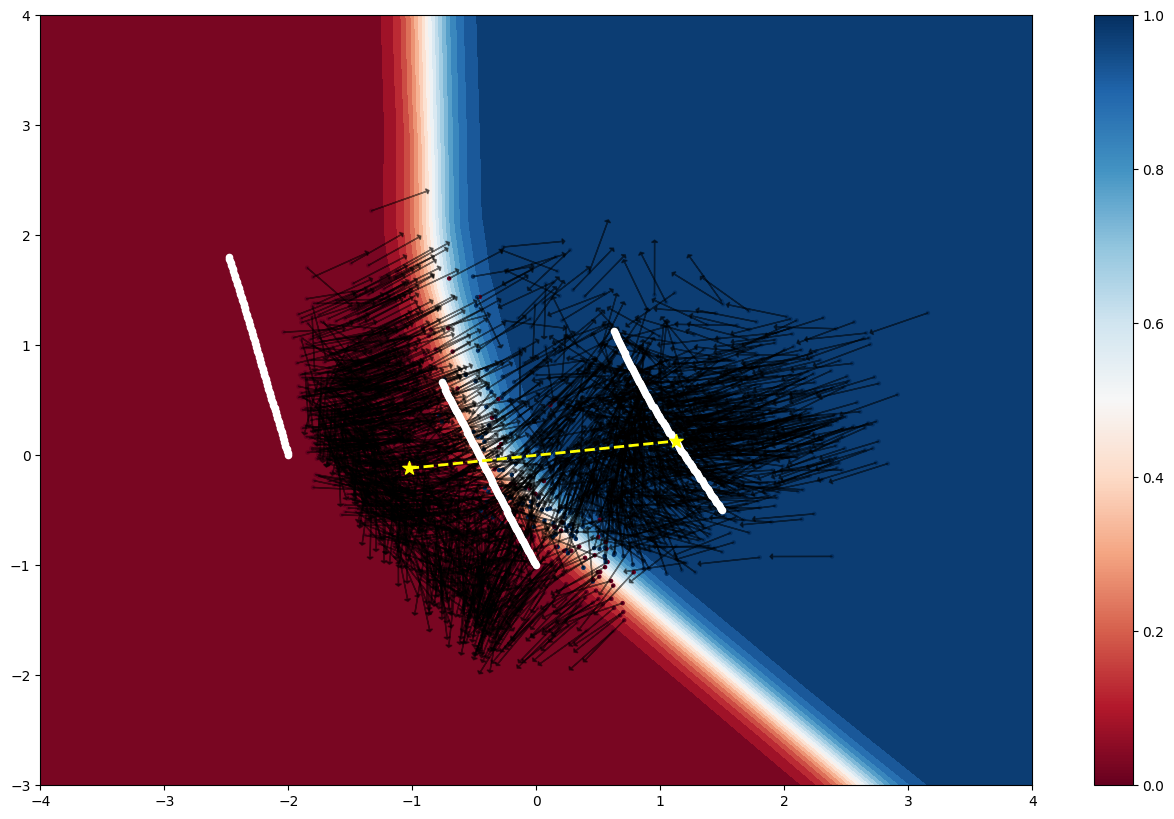

In [323]:
eps = 1e-2  
all_mu = []
all_mu_transformed = []  
labels = []

vae.eval()
generators.eval()
with torch.no_grad():
    for img, label in test_dataloader:
        img = img.to(device)
        mu, logvar = vae.encoder(img)
        
        all_mu.append(mu.cpu())
        labels.append(label)

        mu_transformed = generators(mu)
        all_mu_transformed.append(mu_transformed.cpu())

# Now we have original mu, transformed mu, and true labels
labels = torch.cat(labels, dim=0)
all_mu = torch.cat(all_mu, dim=0)  
all_mu_transformed = torch.cat(all_mu_transformed, dim=1)  

all_mu_transformed = all_mu_transformed[0]    # First Generator

all_mu_transformed = all_mu + eps*all_mu_transformed    # We use the generator as a direction

pca = PCA(n_components=2)
all_mu_2d = pca.fit_transform(all_mu.numpy())
all_mu_transformed_2d = pca.fit_transform(all_mu_transformed.numpy())

x_coords, y_coords = np.meshgrid(np.linspace(-4, 4, 100), np.linspace(-3, 4, 100))
grid_points_2d = torch.tensor(np.stack([x_coords.flatten(), y_coords.flatten()], axis=1)).float().to(device)
grid_points_latent = torch.tensor(pca.inverse_transform(grid_points_2d.cpu().numpy())).float().to(device)    # Mapping PCA dim to latent dim for model to make predicitons

with torch.no_grad():
        preds, logits = oracle(grid_points_latent) 
        grid_preds = preds.cpu().numpy()

plt.figure(figsize=(16,10))
plt.contourf(x_coords, y_coords, grid_preds.reshape(100,100), levels=20, cmap="RdBu")
plt.scatter(all_mu_2d[:,0], all_mu_2d[:,1], c=labels.numpy(), cmap="RdBu", s=5)
plt.colorbar()

# Now we can comput cluster centers and the line between cluster centers
class_centers = []
for c in [0, 1]:
    mask = (labels == c)
    center = all_mu_2d[mask.numpy()].mean(axis=0)
    class_centers.append(center)
class_centers = np.array(class_centers)
plt.scatter(class_centers[:,0], class_centers[:,1], color='yellow', s=100, marker='*', zorder=5)
plt.plot(class_centers[:,0], class_centers[:,1], ls='--', color='yellow', lw=2, zorder=4)

# We need to use the transformed points as directions
arrow_start = all_mu_2d
arrow_end = all_mu_transformed_2d
arrow_vectors = arrow_end - arrow_start
vec_lengths = np.linalg.norm(arrow_vectors, axis=1, keepdims=True)    # Without normalization, the arrows appear too messy
vec_lengths[vec_lengths == 0] = 1 
arrow_vectors_normalized = (arrow_vectors / vec_lengths) * 0.5 
for start, vec in zip(arrow_start, arrow_vectors_normalized):
    plt.arrow(start[0], start[1], vec[0], vec[1], color='k', alpha=0.5, head_width=0.05, head_length=0.02, length_includes_head=True)

# Now, we also need orthogonal paths to the line joining clusters
# For this, we need some initial points
paths = []
path_latents = []
num_steps = 200

start_points = torch.tensor([[0, -1], [-2, 0], [1.5, -0.5]]).float().to(device)
generators.eval()
for point in start_points:
    path_history = []
    with torch.no_grad():
        init_point = torch.tensor(pca.inverse_transform(point.cpu().numpy().reshape(1, -1))).float().to(device)
        init_point = init_point.squeeze(0)
        curr_point = init_point.clone()
        path_history.append(init_point.cpu())

        for i in range(1, num_steps):
            new_point = curr_point + eps*generators(curr_point.unsqueeze(0))[0].squeeze(0)  
            curr_point = new_point
            if (i % 2 == 0):
                path_history.append(new_point.cpu())
    
    path_latent = torch.stack(path_history)
    path_latents.append(path_latent)
    path_2d = pca.transform(path_latent.numpy())
    paths.append(path_2d)

for i, path in enumerate(paths):
    plt.scatter(path[:,0], path[:,1], color="white", s=20, label=f'Path {i+1}', alpha=1)

plt.savefig(f"task3_results/contours.png")
plt.show()
plt.close()

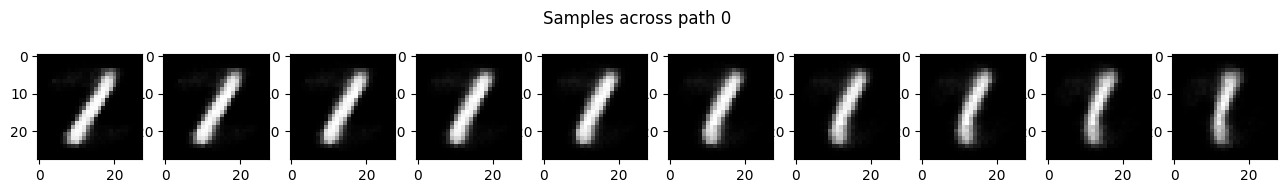

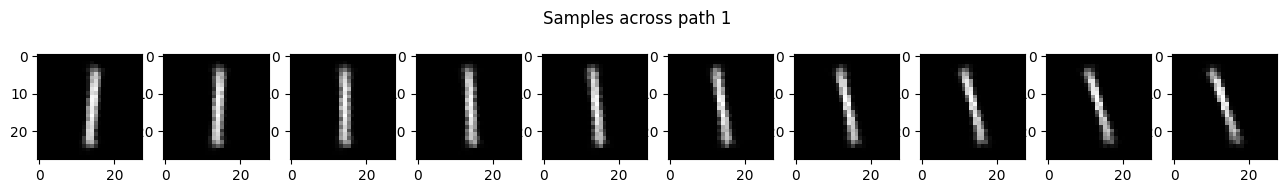

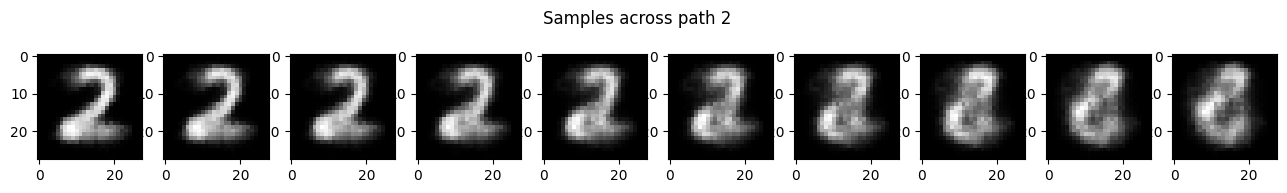

In [325]:
outputs = []
num_samples = 10

step = int(len(path_latents[0]) / num_samples)

vae.eval()
with torch.no_grad():
    for path_latent in path_latents:
        output = []
        for i in range(path_latent.shape[0]):
            if (i % step == 0):
                z = path_latent[i].unsqueeze(0).to(device)
                out = vae.decoder(z)
                output.append(out.squeeze(0).squeeze(0).cpu())
        outputs.append(output)

for path_num, output in enumerate(outputs):
    fig, axes = plt.subplots(1, num_samples, figsize=(16, 2))
    for i in range(num_samples):
        axes[i].imshow(output[i], cmap="gray")
    
    fig.suptitle(f"Samples across path {path_num}")
    plt.savefig(f"task3_results/path_{path_num}_samples.png")
    plt.show()